<span style="color: lightblue">

# ML - PROJEKT ZALICZENIOWY
### 1. Project overview

<span>

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("kukuroo3/body-signal-of-smoking")
df = pd.read_csv(os.path.join(path, "smoking.csv"))
print("Path to dataset files:", path) 


Path to dataset files: /Users/magdalena/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2


#### Problem badawczy: Klasyfikacja osób palących/niepalących na podstawie ich parametrów zdrowotnych

In [3]:
df.head(100)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,118,M,25,175,65,75.0,1.5,1.5,1.0,1.0,...,14.9,1.0,0.7,15.0,13.0,15.0,Y,0,Y,1
96,119,M,40,170,75,89.0,0.8,1.5,1.0,1.0,...,15.8,1.0,0.9,30.0,23.0,35.0,Y,0,N,1
97,120,M,30,175,75,85.1,1.5,1.5,1.0,1.0,...,14.9,1.0,1.1,14.0,16.0,16.0,Y,0,Y,1
98,121,M,35,160,60,80.3,1.0,1.2,1.0,1.0,...,15.9,1.0,0.9,21.0,27.0,39.0,Y,0,N,0


In [4]:
df.shape
print(f"Dataset zawiera {df.shape[0]} obserwacji i {df.shape[1]} kolumn - 26 cech i target '{df.columns[-1]}' - problem binarny, ktorym jest identyfikacja czy badany jest palaczem czy nie.")

Dataset zawiera 55692 obserwacji i 27 kolumn - 26 cech i target 'smoking' - problem binarny, ktorym jest identyfikacja czy badany jest palaczem czy nie.


In [5]:
participant_data = {
    "ID": "Unikalny identyfikator badanego",
    "gender": "Płeć badanego (określone wartości)",
    "age": "Wiek badanego w latach",
    "height(cm)": "Wzrost badanego w centymetrach",
    "weight(kg)": "Waga badanego w kilogramach",
    "waist(cm)": "Obwód talii badanego w centymetrach",
    "eyesight(left)": "Ostrość wzroku w lewym oku",
    "eyesight(right)": "Ostrość wzroku w prawym oku",
    "hearing(left)": "Poziom słuchu w lewym uchu (określone wartości)",
    "hearing(right)": "Poziom słuchu w prawym uchu (określone wartości)",
    "systolic": "Ciśnienie skurczowe krwi badanego",
    "relaxation": "Ciśnienie rozkurczowe krwi badanego",
    "fasting blood sugar": "Poziom glukozy na czczo we krwi badanego",
    "Cholesterol": "Całkowity poziom cholesterolu we krwi",
    "triglyceride": "Poziom trójglicerydów we krwi",
    "HDL": "Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol)",
    "LDL": "Poziom cholesterolu LDL we krwi (tzw. zły cholesterol)",
    "hemoglobin": "Poziom hemoglobiny we krwi badanego",
    "Urine protein": "Zawartość białka w moczu badanego",
    "serum creatinine": "Poziom kreatyniny w surowicy krwi (wskaźnik funkcji nerek)",
    "AST": "Poziom enzymu AST (wskaźnik funkcji wątroby)",
    "ALT": "Poziom enzymu ALT (wskaźnik funkcji wątroby)",
    "Gtp": "Poziom gamma-GTP (wskaźnik funkcji wątroby)",
    "oral": "Stan zdrowia jamy ustnej badanego (ogólna ocena)",
    "dental caries": "Informacja o występowaniu próchnicy",
    "tartar": "Informacja o obecności kamienia nazębnego",
    "smoking": "Informacja o statusie palenia badanego (określone wartości)"
}

print("Semantyczne znaczenie danych ze zbioru:\n")
print("| Dana | Znaczenie |")
print("| :---- | :-------- |")

for key, value in participant_data.items():
    print(f"| {key} | {value} |")


Semantyczne znaczenie danych ze zbioru:

| Dana | Znaczenie |
| :---- | :-------- |
| ID | Unikalny identyfikator badanego |
| gender | Płeć badanego (określone wartości) |
| age | Wiek badanego w latach |
| height(cm) | Wzrost badanego w centymetrach |
| weight(kg) | Waga badanego w kilogramach |
| waist(cm) | Obwód talii badanego w centymetrach |
| eyesight(left) | Ostrość wzroku w lewym oku |
| eyesight(right) | Ostrość wzroku w prawym oku |
| hearing(left) | Poziom słuchu w lewym uchu (określone wartości) |
| hearing(right) | Poziom słuchu w prawym uchu (określone wartości) |
| systolic | Ciśnienie skurczowe krwi badanego |
| relaxation | Ciśnienie rozkurczowe krwi badanego |
| fasting blood sugar | Poziom glukozy na czczo we krwi badanego |
| Cholesterol | Całkowity poziom cholesterolu we krwi |
| triglyceride | Poziom trójglicerydów we krwi |
| HDL | Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol) |
| LDL | Poziom cholesterolu LDL we krwi (tzw. zły cholesterol) |
| hemog

Semantyczne znaczenie danych ze zbioru:

| Dana | Znaczenie |
| :---- | :-------- |
| ID | Unikalny identyfikator badanego |
| gender | Płeć badanego (określone wartości) |
| age | Wiek badanego w latach |
| height(cm) | Wzrost badanego w centymetrach |
| weight(kg) | Waga badanego w kilogramach |
| waist(cm) | Obwód talii badanego w centymetrach |
| eyesight(left) | Ostrość wzroku w lewym oku |
| eyesight(right) | Ostrość wzroku w prawym oku |
| hearing(left) | Poziom słuchu w lewym uchu (określone wartości) |
| hearing(right) | Poziom słuchu w prawym uchu (określone wartości) |
| systolic | Ciśnienie skurczowe krwi badanego |
| relaxation | Ciśnienie rozkurczowe krwi badanego |
| fasting blood sugar | Poziom glukozy na czczo we krwi badanego |
| Cholesterol | Całkowity poziom cholesterolu we krwi |
| triglyceride | Poziom trójglicerydów we krwi |
| HDL | Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol) |
| LDL | Poziom cholesterolu LDL we krwi (tzw. zły cholesterol) |
| hemoglobin | Poziom hemoglobiny we krwi badanego |
| Urine protein | Zawartość białka w moczu badanego |
| serum creatinine | Poziom kreatyniny w surowicy krwi (wskaźnik funkcji nerek) |
| AST | Poziom enzymu AST (wskaźnik funkcji wątroby) |
| ALT | Poziom enzymu ALT (wskaźnik funkcji wątroby) |
| Gtp | Poziom gamma-GTP (wskaźnik funkcji wątroby) |
| oral | Stan zdrowia jamy ustnej badanego (ogólna ocena) |
| dental caries | Informacja o występowaniu próchnicy |
| tartar | Informacja o obecności kamienia nazębnego |
| smoking | Informacja o statusie palenia badanego (określone wartości) |

<span style="color: lightblue">

### 2. EDA - Explanatory data analysis
<span>

In [6]:
df_nulls = pd.DataFrame(df.isnull().sum(axis=0))

In [7]:
df_nulls = pd.DataFrame(df.isnull().sum(axis=0)).reset_index()
df_nulls.columns = ['col_name', 'num_nulls']

In [8]:
print("Lista kolumn w zbiorze danych:")
df_nulls['col_name']

Lista kolumn w zbiorze danych:


0                      ID
1                  gender
2                     age
3              height(cm)
4              weight(kg)
5               waist(cm)
6          eyesight(left)
7         eyesight(right)
8           hearing(left)
9          hearing(right)
10               systolic
11             relaxation
12    fasting blood sugar
13            Cholesterol
14           triglyceride
15                    HDL
16                    LDL
17             hemoglobin
18          Urine protein
19       serum creatinine
20                    AST
21                    ALT
22                    Gtp
23                   oral
24          dental caries
25                 tartar
26                smoking
Name: col_name, dtype: object

In [9]:
print("Braki danych per kolumna:")
df_nulls


Braki danych per kolumna:


,col_name,num_nulls
0,ID,0
1,gender,0
2,age,0
3,height(cm),0
4,weight(kg),0
5,waist(cm),0
6,eyesight(left),0
7,eyesight(right),0
8,hearing(left),0
9,hearing(right),0


In [10]:
if df_nulls['num_nulls'].sum() == 0:
    print("W zbiorze danych nie ma braków danych.")
else:
    print(f"W zbiorze danych jest łącznie {df_nulls['num_nulls'].sum()} braków danych.")

W zbiorze danych nie ma braków danych.


In [11]:
def rename_columns_snake_case(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = [col.lower().replace(" ", "_").replace("(", "_").replace(")", "")  for col in dataframe.columns]
    return dataframe


In [12]:
a = rename_columns_snake_case(df)
a.columns

Index(['id', 'gender', 'age', 'height_cm', 'weight_kg', 'waist_cm',
       'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right',
       'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol',
       'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein',
       'serum_creatinine', 'ast', 'alt', 'gtp', 'oral', 'dental_caries',
       'tartar', 'smoking'],
      dtype='object')

In [741]:
df.rename(columns = {"height(cm)" : "height_cm", "weight(kg)" : "weight_kg",
                     "waist(cm)" : "waist_cm", "eyesight(left)" : "eyesight_left",
                     "eyesight(right)" : "eyesight_right", "hearing(left)" : "hearing_left",
                     "hearing(right)" : "hearing_right", "fasting blood sugar" : "fasting_blood_sugar",
                     "Cholesterol" : "cholesterol", "HDL" : "hdl", "LDL" : "ldl",
                     "Urine protein" : "urine_protein", "serum creatinine" : "serum_creatinine",
                     "AST" : "ast", "ALT" : "alt", "Gtp" : "gtp", "dental caries" : "dental_caries"},
          inplace = True)

In [742]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height_cm            55692 non-null  int64  
 4   weight_kg            55692 non-null  int64  
 5   waist_cm             55692 non-null  float64
 6   eyesight_left        55692 non-null  float64
 7   eyesight_right       55692 non-null  float64
 8   hearing_left         55692 non-null  float64
 9   hearing_right        55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting_blood_sugar  55692 non-null  float64
 13  cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  hdl                  55692 non-null 

In [743]:
df = df.drop(columns=['ID'])

In [744]:
df.describe().round(2)

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,hdl,ldl,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,dental_caries,smoking
count,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,...,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00
mean,44.18,164.65,65.86,82.05,1.01,1.01,1.03,1.03,121.49,76.00,...,57.29,114.96,14.62,1.09,0.89,26.18,27.04,39.95,0.21,0.37
std,12.07,9.19,12.82,9.27,0.49,0.49,0.16,0.16,13.68,9.68,...,14.74,40.93,1.56,0.40,0.22,19.36,30.95,50.29,0.41,0.48
min,20.00,130.00,30.00,51.00,0.10,0.10,1.00,1.00,71.00,40.00,...,4.00,1.00,4.90,1.00,0.10,6.00,1.00,1.00,0.00,0.00
25%,40.00,160.00,55.00,76.00,0.80,0.80,1.00,1.00,112.00,70.00,...,47.00,92.00,13.60,1.00,0.80,19.00,15.00,17.00,0.00,0.00
50%,40.00,165.00,65.00,82.00,1.00,1.00,1.00,1.00,120.00,76.00,...,55.00,113.00,14.80,1.00,0.90,23.00,21.00,25.00,0.00,0.00
75%,55.00,170.00,75.00,88.00,1.20,1.20,1.00,1.00,130.00,82.00,...,66.00,136.00,15.80,1.00,1.00,28.00,31.00,43.00,0.00,1.00
max,85.00,190.00,135.00,129.00,9.90,9.90,2.00,2.00,240.00,146.00,...,618.00,1860.00,21.10,6.00,11.60,1311.00,2914.00,999.00,1.00,1.00


In [745]:
duplicates = df[df.duplicated(keep=False)]
if not duplicates.empty:
    print("Znaleziono zduplikowane obserwacje:")
    print(duplicates)
else:
    print("Nie znaleziono zduplikowanych obserwacji.")

Znaleziono zduplikowane obserwacje:
      gender  age  height_cm  weight_kg  waist_cm  eyesight_left  \
3          M   40        165         70      88.0            1.5   
6          M   40        160         60      85.5            1.0   
7          M   45        165         90      96.0            1.2   
12         M   35        170         70      81.0            1.5   
15         F   40        170         55      68.0            1.0   
...      ...  ...        ...        ...       ...            ...   
55687      F   40        170         65      75.0            0.9   
55688      F   45        160         50      70.0            1.2   
55689      F   55        160         50      68.5            1.0   
55690      M   60        165         60      78.0            0.8   
55691      M   55        160         65      85.0            0.9   

       eyesight_right  hearing_left  hearing_right  systolic  ...  hemoglobin  \
3                 1.5           1.0            1.0     100.0  ... 

In [746]:
df = pd.get_dummies(df, columns=['gender', 'tartar'], prefix=['gender', 'tartar'], drop_first=True)


In [747]:
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,urine_protein,serum_creatinine,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,1.0,0.7,18.0,19.0,27.0,Y,0,0,False,True
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,1.0,0.6,22.0,19.0,18.0,Y,0,0,False,True
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,1.0,21.0,16.0,22.0,Y,0,1,True,False
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,1.0,19.0,26.0,18.0,Y,0,0,True,True
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,1.0,0.6,16.0,14.0,22.0,Y,0,0,False,False


In [748]:
df['smoking'].value_counts(normalize=True)

smoking
0    0.632712
1    0.367288
Name: proportion, dtype: float64

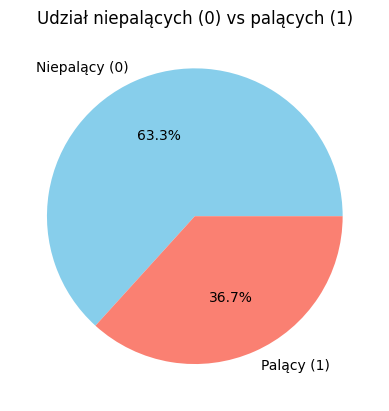

In [749]:
labels = ['Niepalący (0)', 'Palący (1)']

df['smoking'].value_counts(normalize=True).plot(
    kind='pie',
    autopct='%1.1f%%', 
    labels=labels,     
    colors=['skyblue', 'salmon'], 
    title='Udział niepalących (0) vs palących (1)',
    ylabel=''                
)
plt.show()


In [750]:
udzial = df['smoking'].value_counts(normalize=True) * 100
wieksza = udzial.max()
    
if wieksza <= 60:
    print("Dane są dobrze zrównoważone.")
elif wieksza <= 70:
    print("Lekka nierównowaga – akceptowalna.")
elif wieksza <= 80:
    print("Umiarkowana nierównowaga – warto monitorować.")
else:
    print("Silna nierównowaga – zalecane balansowanie danych.")

Lekka nierównowaga – akceptowalna.


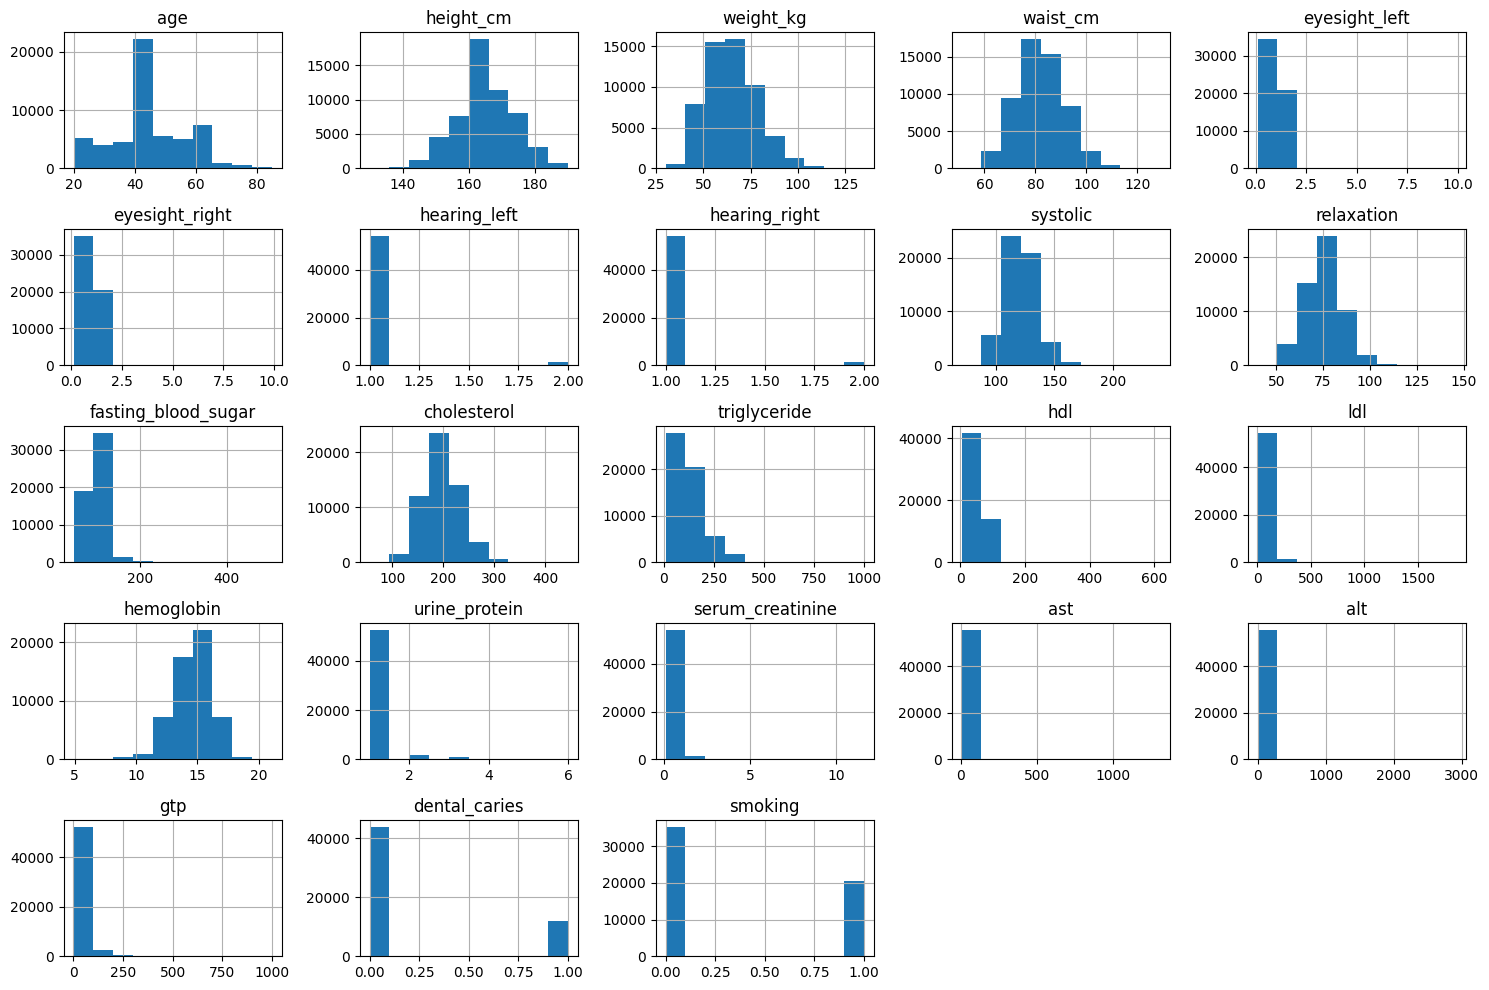

In [751]:
df.hist(figsize=(15, 10), bins=10)
plt.tight_layout()
plt.show()

In [752]:
print(f'Unikalne wartosci w kazdej kolumnie:\n')
df.nunique().sort_values()

Unikalne wartosci w kazdej kolumnie:



oral                     1
hearing_left             2
dental_caries            2
hearing_right            2
gender_M                 2
smoking                  2
tartar_Y                 2
urine_protein            6
height_cm               13
age                     14
eyesight_right          17
eyesight_left           19
weight_kg               22
serum_creatinine        38
relaxation              95
hdl                    126
systolic               130
hemoglobin             145
ast                    219
alt                    245
fasting_blood_sugar    276
cholesterol            286
ldl                    289
triglyceride           390
gtp                    488
waist_cm               566
dtype: int64

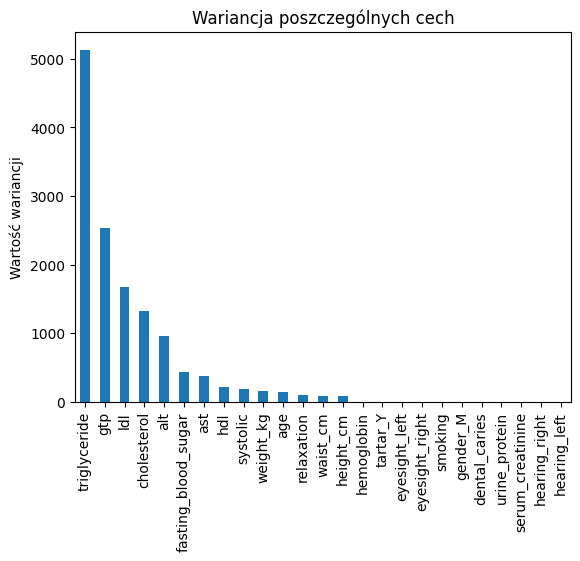

In [753]:
variances = df.var(numeric_only=True).sort_values(ascending=False)
variances.plot(kind='bar')
plt.title("Wariancja poszczególnych cech")
plt.ylabel("Wartość wariancji")
plt.show()

In [754]:
pearson_vars = ['age', 'height_cm', 'weight_kg', 'systolic', 'relaxation', 'hemoglobin']
spearman_vars = ['fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl', 'ast', 'alt', 'gtp', 'serum_creatinine']
kendall_vars = ['hearing_left', 'hearing_right', 'urine_protein', 'dental_caries', 'tartar_Y', 'gender_M']

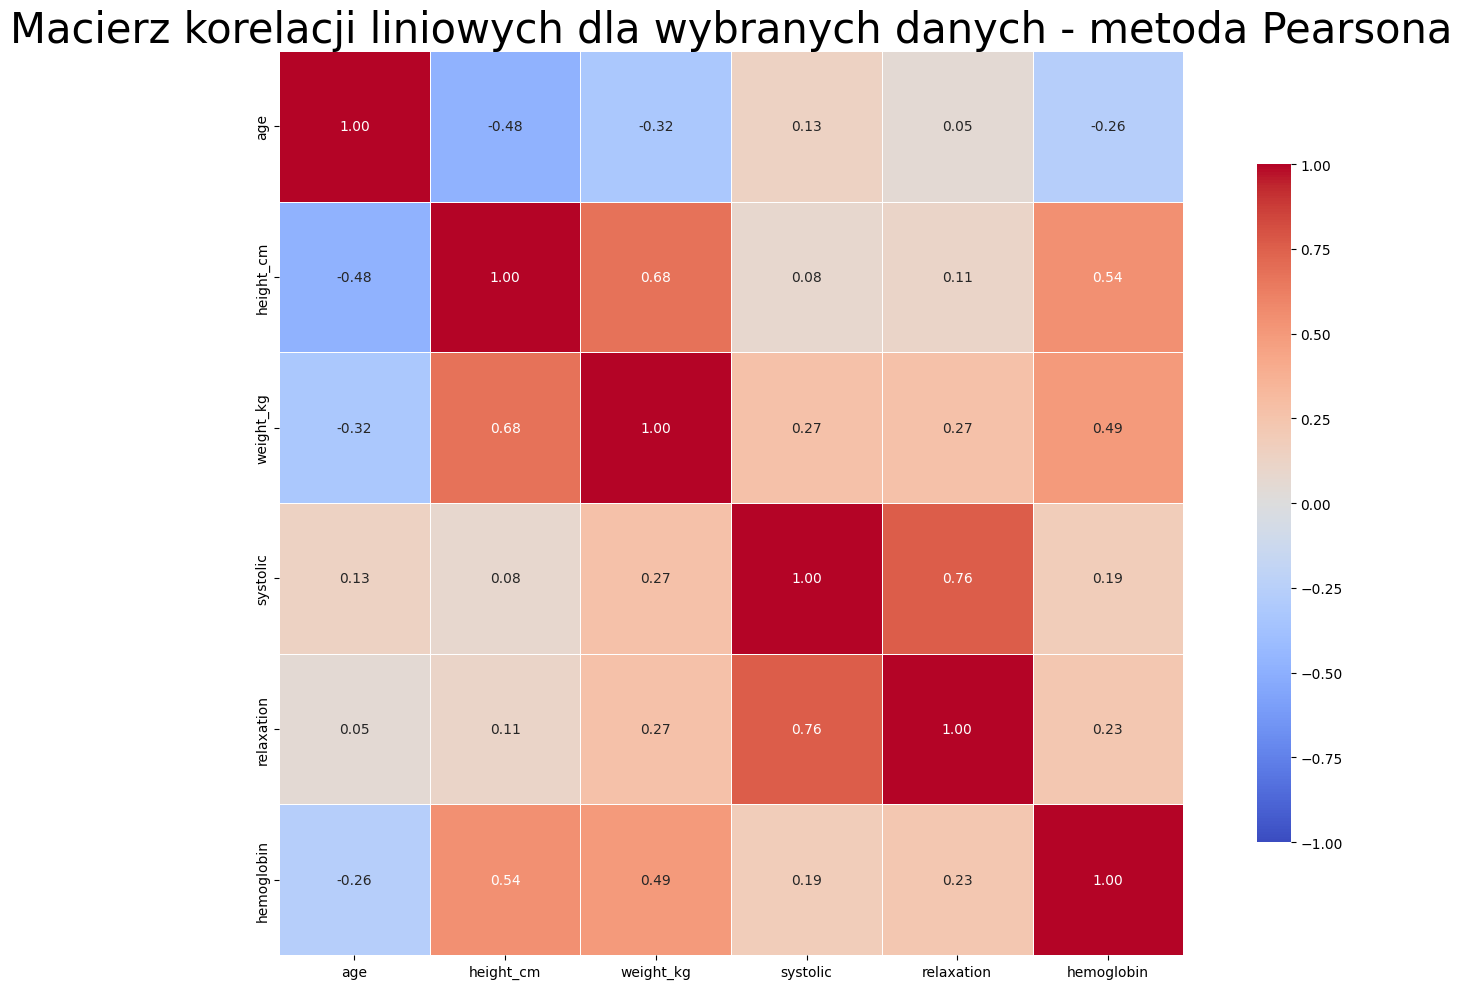

In [755]:
corr = df[pearson_vars].corr(numeric_only=True, method='pearson')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Pearsona", fontsize=30)
plt.tight_layout()
plt.show()

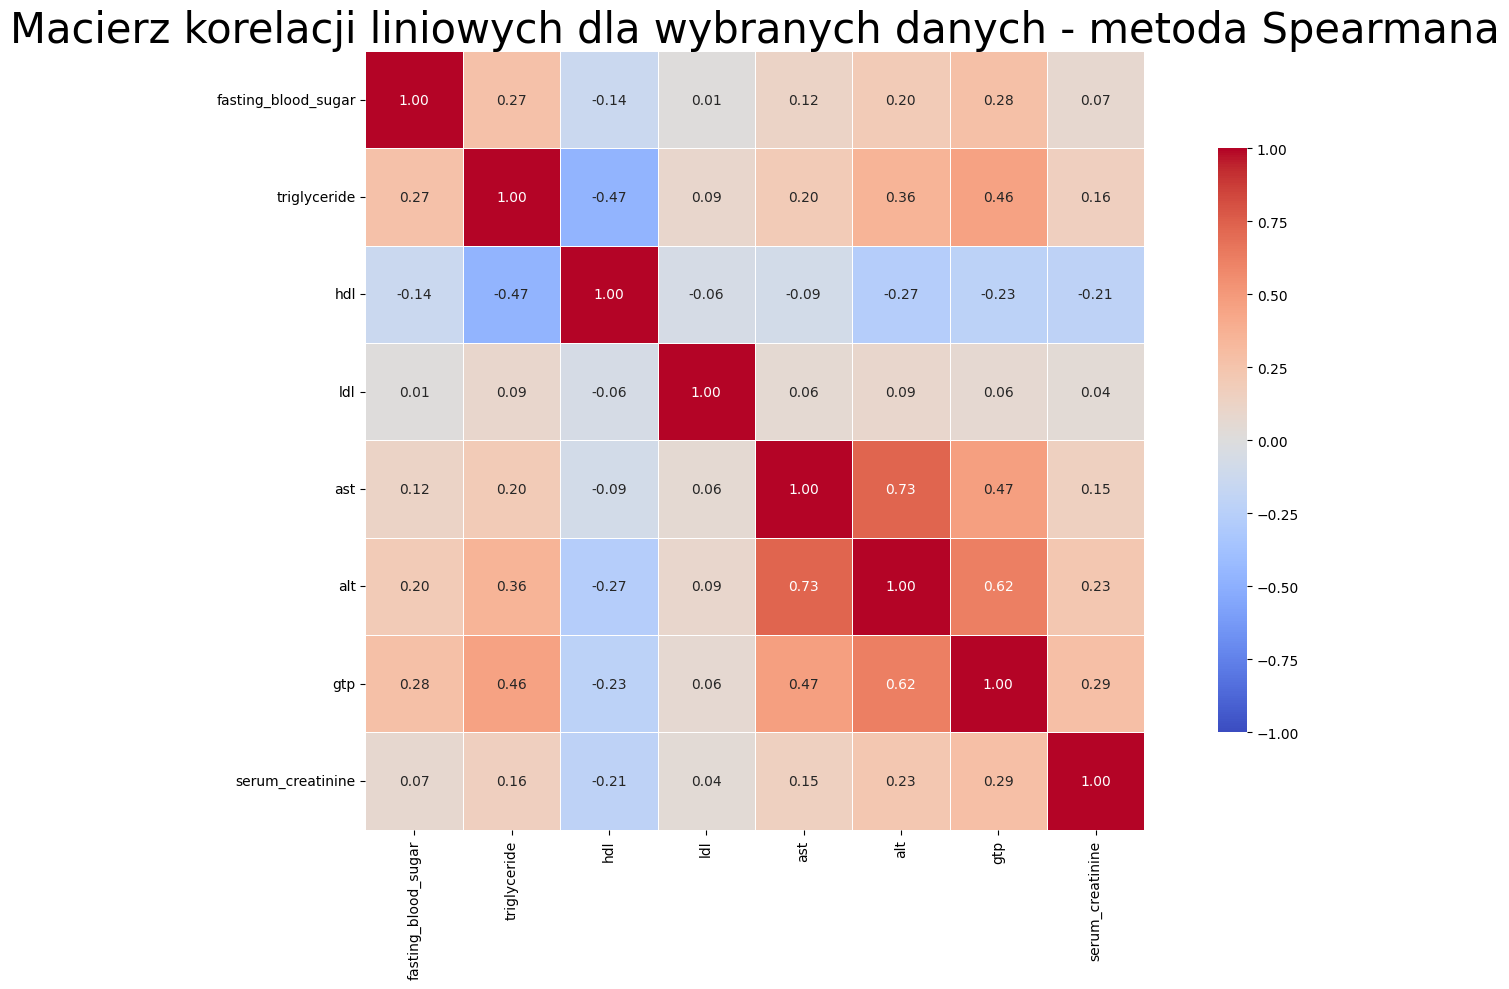

In [756]:
corr = df[spearman_vars].corr(numeric_only=True, method='spearman')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Spearmana", fontsize=30)
plt.tight_layout()
plt.show()

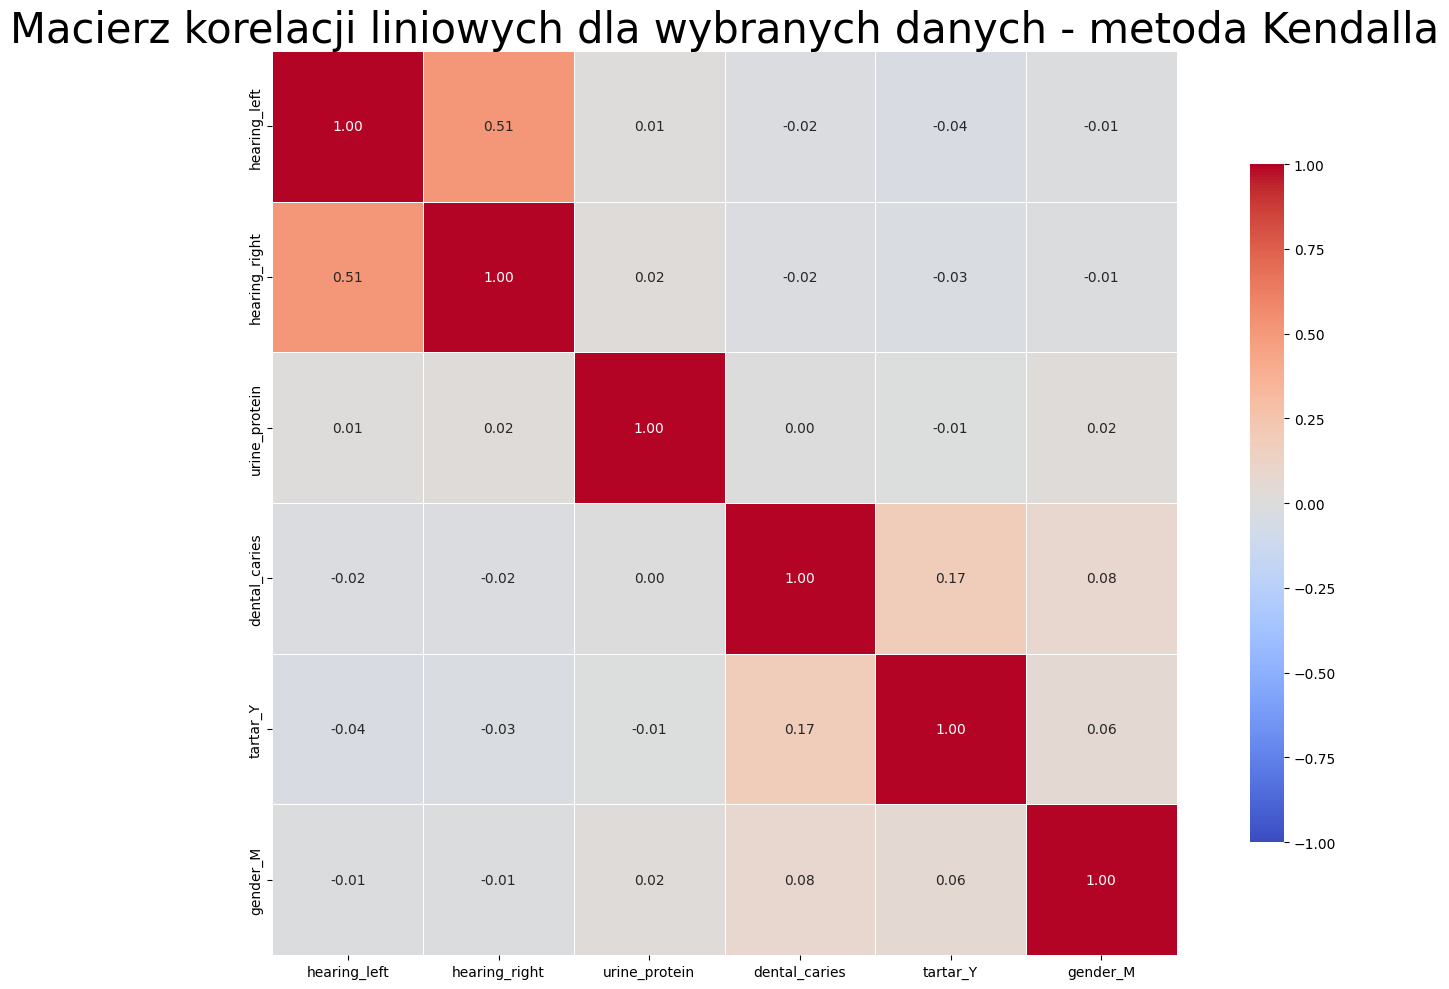

In [757]:
corr = df[kendall_vars].corr(numeric_only=True, method='kendall')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Kendalla", fontsize=30)
plt.tight_layout()
plt.show()

In [758]:
df["pulse_pressure"] = df["systolic"] - df["relaxation"]
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,serum_creatinine,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y,pulse_pressure
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,0.7,18.0,19.0,27.0,Y,0,0,False,True,41.0
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,0.6,22.0,19.0,18.0,Y,0,0,False,True,49.0
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,21.0,16.0,22.0,Y,0,1,True,False,52.0
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,19.0,26.0,18.0,Y,0,0,True,True,40.0
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,0.6,16.0,14.0,22.0,Y,0,0,False,False,46.0


In [759]:
df["BMI"] = (df["weight_kg"]/ (df['height_cm']/100) ** 2).round().astype(int)
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y,pulse_pressure,BMI
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,18.0,19.0,27.0,Y,0,0,False,True,41.0,25
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,22.0,19.0,18.0,Y,0,0,False,True,49.0,23
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,21.0,16.0,22.0,Y,0,1,True,False,52.0,21
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,19.0,26.0,18.0,Y,0,0,True,True,40.0,26
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,16.0,14.0,22.0,Y,0,0,False,False,46.0,25


In [760]:
df["liver_index_ast_alt_gtp_median"] = df[["ast", "alt", "gtp"]].median(axis=1).round().astype(int)

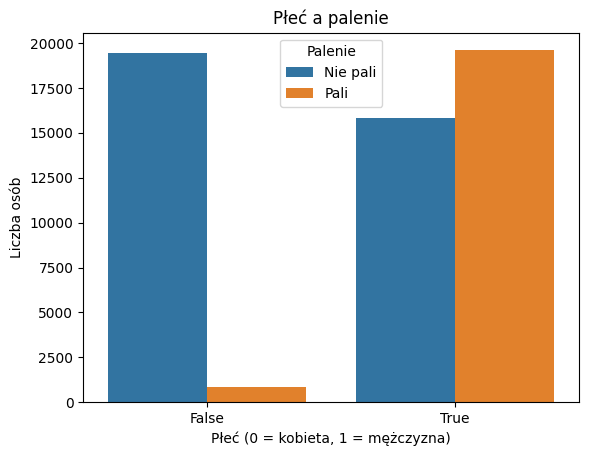

In [761]:
sns.countplot(x='gender_M', hue='smoking', data=df)
plt.title("Płeć a palenie")
plt.xlabel("Płeć (0 = kobieta, 1 = mężczyzna)")
plt.ylabel("Liczba osób")
plt.legend(title="Palenie", labels=["Nie pali", "Pali"])
plt.show()

In [762]:
#gender moze byc zmienna zaklocajaca moze zrobmy dwa modele? a moze tak jest ze tendencja palenia jest wieksza wsrod mezczyzn niz kobiet i model to wychwytuje

In [763]:
cols_to_drop = ['gender_M','waist_cm','cholesterol', 'oral', 'relaxation', 'systolic', 'weight_kg', 'height_cm', 'ast', 'alt', 'gtp']
df = df.drop(cols_to_drop, axis=1)
df.head(100)

,age,eyesight_left,eyesight_right,hearing_left,hearing_right,fasting_blood_sugar,triglyceride,hdl,ldl,hemoglobin,urine_protein,serum_creatinine,dental_caries,smoking,tartar_Y,pulse_pressure,BMI,liver_index_ast_alt_gtp_median
0,40,1.2,1.0,1.0,1.0,94.0,82.0,73.0,126.0,12.9,1.0,0.7,0,0,True,41.0,25,19
1,40,0.8,0.6,1.0,1.0,130.0,115.0,42.0,127.0,12.7,1.0,0.6,0,0,True,49.0,23,19
2,55,0.8,0.8,1.0,1.0,89.0,182.0,55.0,151.0,15.8,1.0,1.0,0,1,False,52.0,21,21
3,40,1.5,1.5,1.0,1.0,96.0,254.0,45.0,226.0,14.7,1.0,1.0,0,0,True,40.0,26,19
4,40,1.0,1.0,1.0,1.0,80.0,74.0,62.0,107.0,12.5,1.0,0.6,0,0,False,46.0,25,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,25,1.5,1.5,1.0,1.0,94.0,92.0,85.0,59.0,14.9,1.0,0.7,0,1,True,58.0,21,15
96,40,0.8,1.5,1.0,1.0,89.0,123.0,57.0,84.0,15.8,1.0,0.9,0,1,False,50.0,26,30
97,30,1.5,1.5,1.0,1.0,92.0,131.0,54.0,140.0,14.9,1.0,1.1,0,1,True,50.0,24,16
98,35,1.0,1.2,1.0,1.0,104.0,87.0,59.0,101.0,15.9,1.0,0.9,0,0,False,44.0,23,27


In [764]:
df.columns

Index(['age', 'eyesight_left', 'eyesight_right', 'hearing_left',
       'hearing_right', 'fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl',
       'hemoglobin', 'urine_protein', 'serum_creatinine', 'dental_caries',
       'smoking', 'tartar_Y', 'pulse_pressure', 'BMI',
       'liver_index_ast_alt_gtp_median'],
      dtype='object')

<span style="color: lightblue">

### 3. Modelling
<span>

In [765]:
X = df.drop('smoking', axis=1)
y = df['smoking']

In [766]:
feature_names = X.columns.tolist()
target_names = y.unique().tolist() 

print("Feature names:", feature_names)
print("Target names:", target_names)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("\nDistribution of target variable:")
print(y.value_counts(normalize=True).round(2))

Feature names: ['age', 'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right', 'fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'dental_caries', 'tartar_Y', 'pulse_pressure', 'BMI', 'liver_index_ast_alt_gtp_median']
Target names: [0, 1]
Number of samples: 55692
Number of features: 17

Distribution of target variable:
smoking
0    0.63
1    0.37
Name: proportion, dtype: float64


In [767]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_scaled = scaler.fit_transform(X_train)
X_ts_scaled = scaler.transform(X_test)


print("Number of training samples:", len(X_tr_scaled))
print("Number of test samples:", len(X_ts_scaled))


Number of training samples: 44553
Number of test samples: 11139


In [768]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_scaled, y_train)

accuracy = model.score(X_ts_scaled, y_test)
print("Model accuracy:", accuracy)

Model accuracy: 0.6982673489541251


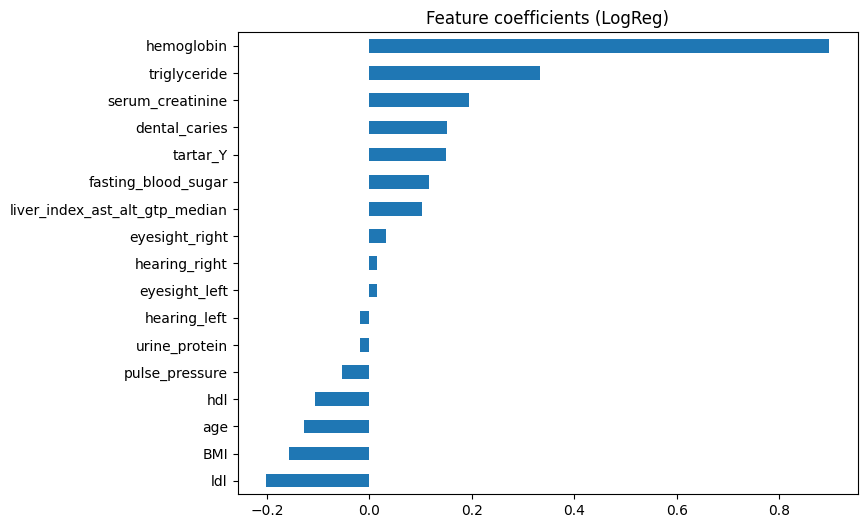

In [769]:
coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
coef.plot(kind='barh', figsize=(8,6))
plt.title("Feature coefficients (LogReg)")
plt.show()


In [770]:

predictions = model.predict(X_ts_scaled)
model.coef_

print("Sample predictions:")
for i in range(5):
    print("Predicted:", predictions[i], "| Actual:", y_test.iloc[i])


print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))



Sample predictions:
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 1
Predicted: 1 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 1 | Actual: 0
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77      7027
           1       0.61      0.51      0.56      4112

    accuracy                           0.70     11139
   macro avg       0.67      0.66      0.66     11139
weighted avg       0.69      0.70      0.69     11139

Confusion Matrix:
[[5677 1350]
 [2011 2101]]


In [771]:
seed = 7
test_size = 0.33
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

model = XGBClassifier()
model.fit(X_train, y_train)

print(model)

y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Accuracy: 74.99%


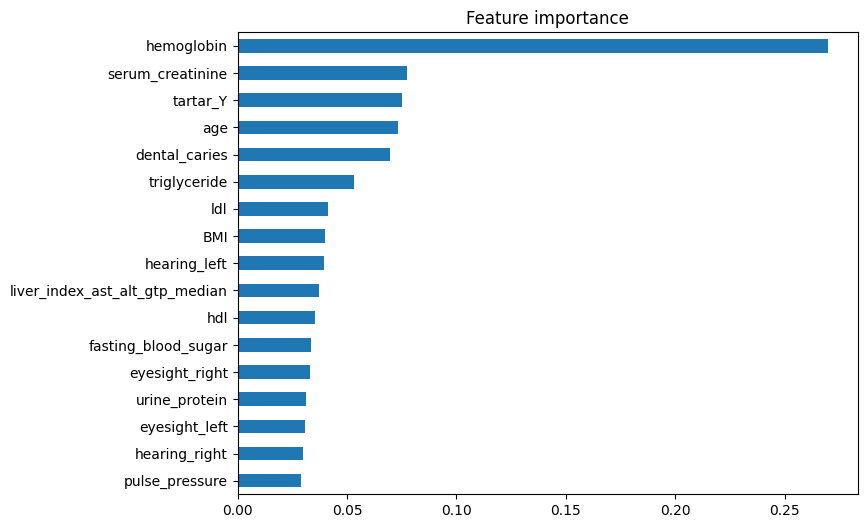

In [772]:
# dla XGBoost / RandomForest
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8,6))
plt.title("Feature importance")
plt.show()

In [773]:
print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80     11648
           1       0.66      0.65      0.65      6731

    accuracy                           0.75     18379
   macro avg       0.73      0.73      0.73     18379
weighted avg       0.75      0.75      0.75     18379

Confusion Matrix:
[[9437 2211]
 [2386 4345]]


<span style="color: lightblue">

### 4. Optimalisation
<span>

<span style="color: lightblue">

### 5. Results interpretation
<span>